In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from pathlib import Path
zip_path = "/content/drive/MyDrive/early-fire-detection/zippy/data.zip"
!unzip -o -q {zip_path} -d /

In [3]:
import sys
from pathlib import Path
PROJECT_ROOT = Path("/content/drive/MyDrive/early-fire-detection")
sys.path.insert(0, str(PROJECT_ROOT))

In [4]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn_v2,
    FasterRCNN_ResNet50_FPN_V2_Weights,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

In [ ]:
from helpers.utils import set_seed, make_run_dir, load_checkpoint, train_detection_run, save_run_config
from helpers.datahelperrr import evaluate_map
from helpers.datahelper import FireDataset, collate_fn

In [6]:
DATA_DIR = Path("/data")
RUNS = PROJECT_ROOT / "models" / "runs"
NUM_CLASSES = 3  # background=0, fire=1, smoke=2
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [7]:
def build_fasterrcnn(num_classes=NUM_CLASSES, trainable_backbone_layers=3, box_batch_size_per_image=512, box_positive_fraction=0.25):
    weights = FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1
    model = fasterrcnn_resnet50_fpn_v2(weights=weights, trainable_backbone_layers=trainable_backbone_layers, box_batch_size_per_image=box_batch_size_per_image, box_positive_fraction=box_positive_fraction)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    model.transform.min_size = (640,)
    model.transform.max_size = 640
    return model

In [8]:
train_ds = FireDataset(DATA_DIR / "train", augment=True)
val_ds = FireDataset(DATA_DIR / "val", augment=False)
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, collate_fn=collate_fn, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, collate_fn=collate_fn, num_workers=4, pin_memory=True)

In [ ]:
lr_sweep = [0.001, 0.005, 0.01, 0.02]
results = []

for lr in lr_sweep:
    lr_tag = str(lr).replace(".", "")
    set_seed(42)
    model = build_fasterrcnn(num_classes=NUM_CLASSES, trainable_backbone_layers=3).to(device)
    model.to(device)
    load_checkpoint(RUNS / "fasterrcnn_v2_freeze_head" / "weights" / "best.pt", model)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=0.0005)
    run_dir = make_run_dir(RUNS, f"fasterrcnn_v2_unfreeze_l3_lr{lr_tag}_hyper")
    save_run_config(run_dir, {
        "lr": lr,
        "epochs": 10,
        "trainable_backbone_layers": 3,
        "optimizer": "SGD",
        "momentum": 0.9,
        "weight_decay": 0.0005,
        "batch_size": 8,
        "augment": True,
        "seed": 42,
        "start_checkpoint": "fasterrcnn_v2_freeze_head/weights/best.pt",
    })

    try: 
        train_detection_run(model, optimizer, train_loader, val_loader, device, run_dir, epochs=10)
        df = pd.read_csv(run_dir / "metrics.csv")
        best = df.loc[df["map50"].idxmax()]
        results.append({
            "run": run_dir.name,
            "lr": lr,
            "best_epoch": int(best["epoch"]),
            "map50": float(best["map50"]),
            "map75": float(best["map75"]),
            "ap50_fire": float(best["ap50_fire"]),
            "ap50_smoke": float(best["ap50_smoke"]),
            "val_total": float(best["val_total"]),
        })
    except Exception as e:
        print(f"Training failed for {lr}: {e}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 239MB/s] 


Epoch 1, Step 200, Loss: 0.136032657250762
Epoch 1, Step 400, Loss: 0.13698656703345477
AP@0.50  fire: 0.918
AP@0.50  smoke: 0.859
mAP@0.50: 0.889
AP@0.75  fire: 0.651
AP@0.75  smoke: 0.383
mAP@0.75: 0.517
Epoch 1: val_total 0.13265074613544106, map50 0.8887831870738232, map75 0.5167389454299297, 178.5014410018921s
Epoch 2, Step 200, Loss: 0.12126646714285017
Epoch 2, Step 400, Loss: 0.11944783383049071
AP@0.50  fire: 0.947
AP@0.50  smoke: 0.882
mAP@0.50: 0.914
AP@0.75  fire: 0.703
AP@0.75  smoke: 0.542
mAP@0.75: 0.623
Epoch 2: val_total 0.11944180585306846, map50 0.9140694917373997, map75 0.6229305174484168, 176.68602013587952s
Epoch 3, Step 200, Loss: 0.10831738835200667
Epoch 3, Step 400, Loss: 0.11021336353383958
AP@0.50  fire: 0.957
AP@0.50  smoke: 0.896
mAP@0.50: 0.926
AP@0.75  fire: 0.718
AP@0.75  smoke: 0.476
mAP@0.75: 0.597
Epoch 3: val_total 0.11161745787581052, map50 0.9262171260294255, map75 0.5970488682213808, 177.0595109462738s
Epoch 4, Step 200, Loss: 0.10519118815660476

In [ ]:
LR_RUNS = [
    "fasterrcnn_v2_unfreeze_l3_lr0001_hyper",
    "fasterrcnn_v2_unfreeze_l3_lr0005_hyper",
    "fasterrcnn_v2_unfreeze_l3_lr001_hyper",
    "fasterrcnn_v2_unfreeze_l3_lr002_hyper",
]

rows = []
for name in LR_RUNS:
    tag = name.split("_lr")[1].replace("_hyper", "")
    lr = float("0." + tag[1:])
    df = pd.read_csv(RUNS / name / "metrics.csv")
    best = df.loc[df["map50"].idxmax()]
    rows.append({
        "run": name,
        "lr": lr,
        "best_epoch": int(best["epoch"]),
        "map50": float(best["map50"]),
        "map75": float(best["map75"]),
        "ap50_fire": float(best["ap50_fire"]),
        "ap50_smoke": float(best["ap50_smoke"]),
        "val_total": float(best["val_total"]),
    })

summary = pd.DataFrame(rows).sort_values("lr")
summary.to_csv(RUNS / "lr_sweep_e10_summary.csv", index=False)
summary

,run,lr,best_epoch,map50,map75,ap50_fire,ap50_smoke,val_total
0,fasterrcnn_v2_unfreeze_l3_lr0001_hyper,0.001,10,0.939505,0.661770,0.962313,0.916698,0.105472
1,fasterrcnn_v2_unfreeze_l3_lr0005_hyper,0.005,9,0.947919,0.700972,0.966278,0.929559,0.102411
2,fasterrcnn_v2_unfreeze_l3_lr001_hyper,0.010,10,0.941196,0.664190,0.960229,0.922162,0.104529
3,fasterrcnn_v2_unfreeze_l3_lr002_hyper,0.020,9,0.933611,0.628419,0.956832,0.910390,0.112497


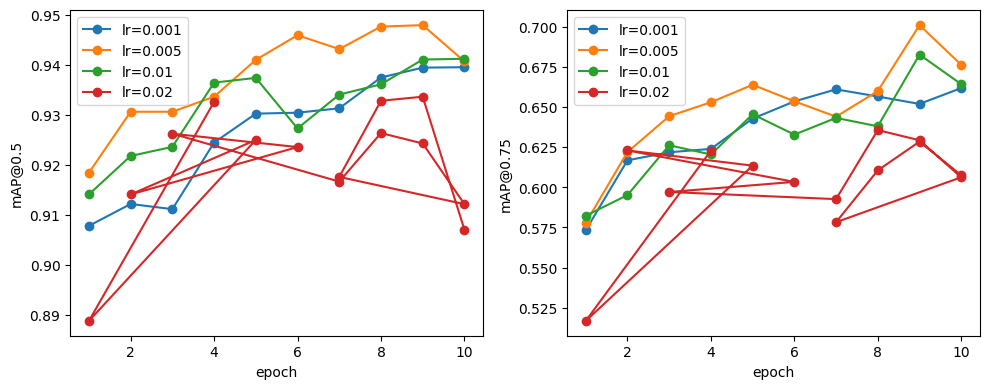

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for name in LR_RUNS:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    tag = name.split("_lr")[1].replace("_hyper", "")
    lr = float("0." + tag[1:])
    ax[0].plot(df["epoch"], df["map50"], marker="o", label=f"lr={lr}")
    ax[1].plot(df["epoch"], df["map75"], marker="o", label=f"lr={lr}")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("mAP@0.5")
ax[0].legend()
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("mAP@0.75")
ax[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
WD_RUNS = [
    {"name": "wd0", "weight_decay": 0.0},
    {"name": "wd1e4", "weight_decay": 1e-4},
    {"name": "wd1e3", "weight_decay": 1e-3},
]

results = []
for spec in WD_RUNS:
    set_seed(42)
    model = build_fasterrcnn(trainable_backbone_layers=3)
    model.to(device)
    load_checkpoint(RUNS / "fasterrcnn_v2_freeze_head" / "weights" / "best.pt", model)
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(
        params, lr=0.005, momentum=0.9, weight_decay=spec["weight_decay"],
    )
    run_dir = make_run_dir(RUNS, f"fasterrcnn_v2_unfreeze_l3_{spec['name']}_hyper")
    save_run_config(run_dir, {
        "lr": 0.005,
        "weight_decay": spec["weight_decay"],
        "epochs": 10,
        "schedule": "constant",
        "trainable_backbone_layers": 3,
        "optimizer": "SGD",
        "start_checkpoint": "fasterrcnn_v2_freeze_head/weights/best.pt",
    })
    try:
        train_detection_run(
            model, optimizer, train_loader, val_loader, device, run_dir, epochs=10,
        )
        df = pd.read_csv(run_dir / "metrics.csv")
        best = df.loc[df["map50"].idxmax()]
        results.append({
            "run": run_dir.name,
            "weight_decay": spec["weight_decay"],
            "best_epoch": int(best["epoch"]),
            "map50": float(best["map50"]),
            "map75": float(best["map75"]),
            "val_total": float(best["val_total"]),
        })
    except Exception as e:
        print(f"Failed: {spec['name']}: {e}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 239MB/s] 


Epoch 1, Step 200, Loss: 0.11334266209974884
Epoch 1, Step 400, Loss: 0.11431341486051678
AP@0.50  fire: 0.956
AP@0.50  smoke: 0.880
mAP@0.50: 0.918
AP@0.75  fire: 0.732
AP@0.75  smoke: 0.481
mAP@0.75: 0.607
Epoch 1: val_total 0.11293337747820316, map50 0.9181967764486942, map75 0.6065311286284442, 179.6542317867279s
Epoch 2, Step 200, Loss: 0.10765774054452777
Epoch 2, Step 400, Loss: 0.10532564913854003
AP@0.50  fire: 0.959
AP@0.50  smoke: 0.888
mAP@0.50: 0.924
AP@0.75  fire: 0.693
AP@0.75  smoke: 0.540
mAP@0.75: 0.616
Epoch 2: val_total 0.11187194911705936, map50 0.9235420035010378, map75 0.6164824505831062, 175.55367803573608s
Epoch 3, Step 200, Loss: 0.09450807021930814
Epoch 3, Step 400, Loss: 0.0965494797937572
AP@0.50  fire: 0.966
AP@0.50  smoke: 0.900
mAP@0.50: 0.933
AP@0.75  fire: 0.763
AP@0.75  smoke: 0.549
mAP@0.75: 0.656
Epoch 3: val_total 0.1074063456817273, map50 0.9332957246743228, map75 0.6556347601583319, 176.10318112373352s
Epoch 4, Step 200, Loss: 0.0893355052545666

In [ ]:
WD_NAMES = [
    ("fasterrcnn_v2_unfreeze_l3_wd0_hyper", 0.0),
    ("fasterrcnn_v2_unfreeze_l3_wd1e4_hyper", 1e-4),
    ("fasterrcnn_v2_unfreeze_l3_lr0005_hyper", 5e-4),
    ("fasterrcnn_v2_unfreeze_l3_wd1e3_hyper", 1e-3),
]
rows = []
for name, wd in WD_NAMES:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    best = df.loc[df["map50"].idxmax()]
    rows.append({
        "run": name,
        "weight_decay": wd,
        "best_epoch": int(best["epoch"]),
        "map50": float(best["map50"]),
        "map75": float(best["map75"]),
        "val_total": float(best["val_total"]),
    })
pd.DataFrame(rows)

,run,weight_decay,best_epoch,map50,map75,val_total
0,fasterrcnn_v2_unfreeze_l3_wd0_hyper,0.0000,5,0.946533,0.689818,0.103037
1,fasterrcnn_v2_unfreeze_l3_wd1e4_hyper,0.0001,8,0.951420,0.655366,0.102877
2,fasterrcnn_v2_unfreeze_l3_lr0005_hyper,0.0005,9,0.947919,0.700972,0.102411
3,fasterrcnn_v2_unfreeze_l3_wd1e3_hyper,0.0010,9,0.948297,0.689591,0.101154


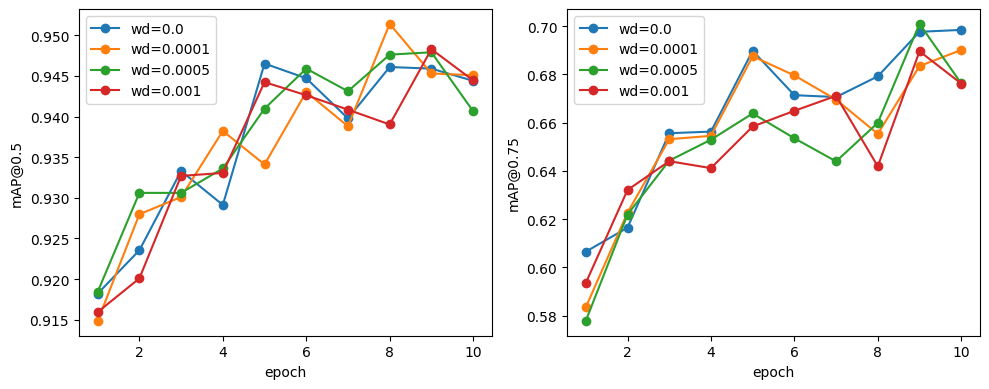

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for name, wd in WD_NAMES:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    label = f"wd={wd}"
    ax[0].plot(df["epoch"], df["map50"], marker="o", label=label)
    ax[1].plot(df["epoch"], df["map75"], marker="o", label=label)
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("mAP@0.5")
ax[0].legend()
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("mAP@0.75")
ax[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
LAYER_RUNS = [
    {"name": "l1", "layers": 1},
    {"name": "l2", "layers": 2},
    {"name": "l4", "layers": 4},
    {"name": "l5", "layers": 5},
]

results = []
for spec in LAYER_RUNS:
    set_seed(42)
    model = build_fasterrcnn(trainable_backbone_layers=spec["layers"])
    model.to(device)
    load_checkpoint(RUNS / "fasterrcnn_v2_freeze_head" / "weights" / "best.pt", model)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
    run_dir = make_run_dir(RUNS, f"fasterrcnn_v2_unfreeze_{spec['name']}_hyper")
    save_run_config(run_dir, {
        "lr": 0.005,
        "weight_decay": 0.0005,
        "epochs": 10,
        "trainable_backbone_layers": spec["layers"],
        "optimizer": "SGD",
        "start_checkpoint": "fasterrcnn_v2_freeze_head/weights/best.pt",
    })

    try:
        train_detection_run(
            model, optimizer, train_loader, val_loader, device, run_dir, epochs=10,
        )
        df = pd.read_csv(run_dir / "metrics.csv")
        best = df.loc[df["map50"].idxmax()]
        results.append({
            "run": run_dir.name,
            "layers": spec["layers"],
            "best_epoch": int(best["epoch"]),
            "map50": float(best["map50"]),
            "map75": float(best["map75"]),
            "val_total": float(best["val_total"]),
        })
    except Exception as e:
        print(f"failed {spec['name']}: {e}")

Epoch 1, Step 200, Loss: 0.11270435193553567
Epoch 1, Step 400, Loss: 0.1135930703766644
AP@0.50  fire: 0.945
AP@0.50  smoke: 0.844
mAP@0.50: 0.895
AP@0.75  fire: 0.683
AP@0.75  smoke: 0.408
mAP@0.75: 0.545
Epoch 1: val_total 0.1186570448149567, map50 0.894510319744239, map75 0.5454213015400647, 164.61624002456665s
Epoch 2, Step 200, Loss: 0.11047425173223019
Epoch 2, Step 400, Loss: 0.10929089583456517
AP@0.50  fire: 0.949
AP@0.50  smoke: 0.846
mAP@0.50: 0.898
AP@0.75  fire: 0.683
AP@0.75  smoke: 0.474
mAP@0.75: 0.578
Epoch 2: val_total 0.11932287481756298, map50 0.897808084591867, map75 0.5782210988802087, 164.667582988739s
Epoch 3, Step 200, Loss: 0.10206847794353963
Epoch 3, Step 400, Loss: 0.10367836136370898
AP@0.50  fire: 0.954
AP@0.50  smoke: 0.869
mAP@0.50: 0.912
AP@0.75  fire: 0.723
AP@0.75  smoke: 0.484
mAP@0.75: 0.604
Epoch 3: val_total 0.11836053168206859, map50 0.9116308282216059, map75 0.6035549874738324, 165.1021375656128s
Epoch 4, Step 200, Loss: 0.09812003757804633
Ep

In [ ]:
LAYER_NAMES = [
    ("fasterrcnn_v2_unfreeze_l1_hyper", 1),
    ("fasterrcnn_v2_unfreeze_l2_hyper", 2),
    ("fasterrcnn_v2_unfreeze_l3_lr0005_hyper", 3),
    ("fasterrcnn_v2_unfreeze_l4_hyper", 4),
    ("fasterrcnn_v2_unfreeze_l5_hyper", 5),
]

rows = []
for name, layers in LAYER_NAMES: 
    df = pd.read_csv(RUNS / name / "metrics.csv")
    best = df.loc[df["map50"].idxmax()]
    rows.append({
        "run": name,
        "layers": layers,
        "best_epoch": int(best["epoch"]),
        "map50": float(best["map50"]),
        "map75": float(best["map75"]),
        "val_total": float(best["val_total"]),
    })

In [ ]:
pd.DataFrame(rows)

,run,layers,best_epoch,map50,map75,val_total
0,fasterrcnn_v2_unfreeze_l1_hyper,1,10,0.935434,0.642691,0.113192
1,fasterrcnn_v2_unfreeze_l2_hyper,2,9,0.942973,0.656577,0.108314
2,fasterrcnn_v2_unfreeze_l3_lr0005_hyper,3,9,0.947919,0.700972,0.102411
3,fasterrcnn_v2_unfreeze_l4_hyper,4,9,0.948366,0.685819,0.100443
4,fasterrcnn_v2_unfreeze_l5_hyper,5,8,0.952135,0.683765,0.101252


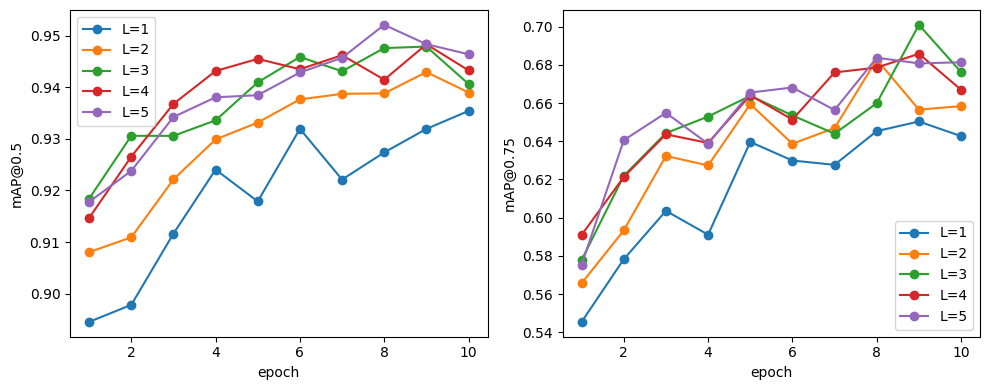

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for name, layers in LAYER_NAMES:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    ax[0].plot(df["epoch"], df["map50"], marker="o", label=f"L={layers}")
    ax[1].plot(df["epoch"], df["map75"], marker="o", label=f"L={layers}")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("mAP@0.5"); ax[0].legend()
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("mAP@0.75"); ax[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
OPTIMIZER_RUNS = ["sgd_nesterov", "adam", "adamw", "rmsprop"]

results = []
for name in OPTIMIZER_RUNS:
    set_seed(42)
    model= build_fasterrcnn(trainable_backbone_layers=3)
    model.to(device)
    load_checkpoint(RUNS / "fasterrcnn_v2_freeze_head" / "weights" / "best.pt", model)

    params = [p for p in model.parameters() if p.requires_grad]
    if name == "sgd_nesterov":
        optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, nesterov=True)
    elif name == "adamw":
        optimizer = torch.optim.AdamW(params, lr=0.005, weight_decay=0.0005)
    elif name == "rmsprop":
        optimizer = torch.optim.RMSprop(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

    run_dir = make_run_dir(RUNS, f"fasterrcnn_v2_unfreeze_l3_{name}_hyper")
    save_run_config(run_dir, {"optimizer": name,
        "lr": 0.005,
        "weight_decay": 0.0005,
        "epochs": 10,
        "trainable_backbone_layers": 3,
        "start_checkpoint": "fasterrcnn_v2_freeze_head/weights/best.pt",
    })

    try:
        train_detection_run(model, optimizer, train_loader, val_loader, device, run_dir, epochs=10)
        df=pd.read_csv(run_dir / "metrics.csv")
        best = df.loc[df["map50"].idxmax()]
        results.append({
            "run": run_dir.name,
            "optimizer": name,
            "lr": 0.005,
            "best_epoch": int(best["epoch"]),
            "map50": float(best["map50"]),
            "map75": float(best["map75"]),
            "val_total": float(best["val_total"]),
        })
    except Exception as e:
        print(f"failed: {name}: {e}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 217MB/s]  


Epoch 1, Step 200, Loss: 0.11279817778617143
Epoch 1, Step 400, Loss: 0.11364413452334703
AP@0.50  fire: 0.957
AP@0.50  smoke: 0.877
mAP@0.50: 0.917
AP@0.75  fire: 0.711
AP@0.75  smoke: 0.451
mAP@0.75: 0.581
Epoch 1: val_total 0.11333746362500395, map50 0.9168242432933361, map75 0.5810698225815003, 178.01170802116394s
Epoch 2, Step 200, Loss: 0.10649791089817881
Epoch 2, Step 400, Loss: 0.10446376792155206
AP@0.50  fire: 0.961
AP@0.50  smoke: 0.888
mAP@0.50: 0.924
AP@0.75  fire: 0.701
AP@0.75  smoke: 0.538
mAP@0.75: 0.620
Epoch 2: val_total 0.11099445303342094, map50 0.9243111261109833, map75 0.619855258383011, 176.16194653511047s
Epoch 3, Step 200, Loss: 0.09432280033826829
Epoch 3, Step 400, Loss: 0.09570416932925582
AP@0.50  fire: 0.960
AP@0.50  smoke: 0.905
mAP@0.50: 0.933
AP@0.75  fire: 0.747
AP@0.75  smoke: 0.530
mAP@0.75: 0.638
Epoch 3: val_total 0.1059504791728558, map50 0.9326694936121968, map75 0.6382897438072642, 176.63538599014282s
Epoch 4, Step 200, Loss: 0.087954512964934

In [ ]:
pd.DataFrame(results)

,run,optimizer,lr,best_epoch,map50,map75,val_total
0,fasterrcnn_v2_unfreeze_l3_sgd_nesterov_hyper,sgd_nesterov,0.005,9,0.954160,0.688848,0.100375
1,fasterrcnn_v2_unfreeze_l3_adam_hyper,adam,0.005,3,0.891222,0.529421,0.121031
2,fasterrcnn_v2_unfreeze_l3_adamw_hyper,adamw,0.005,10,0.611902,0.130994,0.140698
3,fasterrcnn_v2_unfreeze_l3_rmsprop_hyper,rmsprop,0.005,1,0.000000,0.000000,4.335636


Adam, AdamW and RMSprop all used the same lr=0.005 that we picked for SGD. None of them trained properly. Adam stayed stuck near the freeze-head score. AdamW wrecked the weights in epoch 1 and only recovered to 0.61.RMSprop blew up.Adaptive optimizers usually need a much smaller lr, so this is not a fair test but in literature and documentations of torchvision, SGD based optimizers are best practise

In [ ]:
OPT_NAMES = [
    ("fasterrcnn_v2_unfreeze_l3_lr0005_hyper", "sgd_momentum"),
    ("fasterrcnn_v2_unfreeze_l3_sgd_nesterov_hyper", "sgd_nesterov"),
    ("fasterrcnn_v2_unfreeze_l3_adam_hyper", "adam"),
    ("fasterrcnn_v2_unfreeze_l3_adamw_hyper", "adamw"),
    ("fasterrcnn_v2_unfreeze_l3_rmsprop_hyper", "rmsprop"),
]
rows = []
for name, opt in OPT_NAMES:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    best = df.loc[df["map50"].idxmax()]
    rows.append({
        "run": name,
        "optimizer": opt,
        "best_epoch": int(best["epoch"]),
        "map50": float(best["map50"]),
        "map75": float(best["map75"]),
        "val_total": float(best["val_total"]),
    })
pd.DataFrame(rows)

,run,optimizer,best_epoch,map50,map75,val_total
0,fasterrcnn_v2_unfreeze_l3_lr0005_hyper,sgd_momentum,9,0.947919,0.700972,0.102411
1,fasterrcnn_v2_unfreeze_l3_sgd_nesterov_hyper,sgd_nesterov,9,0.954160,0.688848,0.100375
2,fasterrcnn_v2_unfreeze_l3_adam_hyper,adam,3,0.891222,0.529421,0.121031
3,fasterrcnn_v2_unfreeze_l3_adamw_hyper,adamw,10,0.611902,0.130994,0.140698
4,fasterrcnn_v2_unfreeze_l3_rmsprop_hyper,rmsprop,1,0.000000,0.000000,4.335636


even though for map50 nesterov is higher, we prefer to use momentum version because of map75

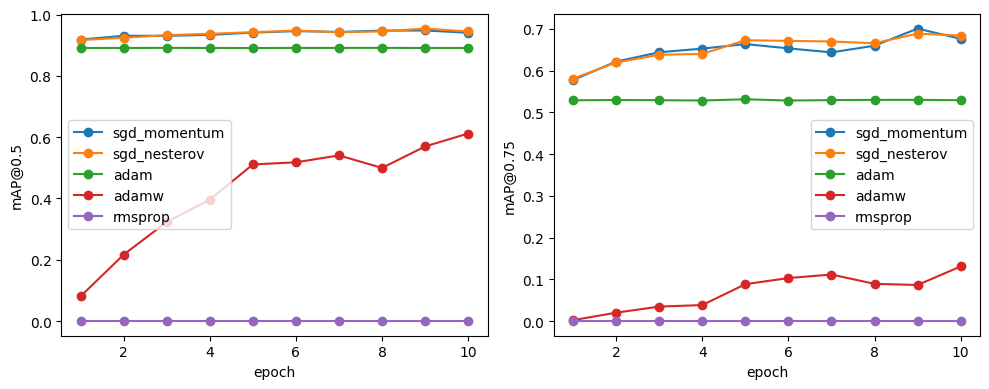

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for name, opt in OPT_NAMES:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    ax[0].plot(df["epoch"], df["map50"], marker="o", label=opt)
    ax[1].plot(df["epoch"], df["map75"], marker="o", label=opt)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("mAP@0.5"); ax[0].legend()
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("mAP@0.75"); ax[1].legend()
plt.tight_layout()
plt.show()

The RPN generates many possible object boxes but the box head trains on only a sample of them. box_batch_size_per_image controls how many proposals are selected while box_positive_fraction limits how many can represent real objects.

Since our images usually contain only a few fire or smoke objects we tested whether using fewer proposals or allowing more positives would help.

In [10]:
ROI_SAMPLE_RUNS = [
    # baseline posfrac025_bs512 = fasterrcnn_v2_unfreeze_l3_lr0005_hyper
    {"name": "posfrac025_bs256", "box_positive_fraction": 0.25, "box_batch_size_per_image": 256},
    {"name": "posfrac025_bs128", "box_positive_fraction": 0.25, "box_batch_size_per_image": 128},
    {"name": "posfrac050_bs128", "box_positive_fraction": 0.50, "box_batch_size_per_image": 128},
]

results = []
for spec in ROI_SAMPLE_RUNS:
    set_seed(42)
    model = build_fasterrcnn(
        trainable_backbone_layers=3,
        box_positive_fraction=spec["box_positive_fraction"],
        box_batch_size_per_image=spec["box_batch_size_per_image"],
    )
    model.to(device)
    load_checkpoint(RUNS / "fasterrcnn_v2_freeze_head" / "weights" / "best.pt", model)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
    run_dir = make_run_dir(RUNS, f"fasterrcnn_v2_unfreeze_l3_{spec['name']}_hyper")
    save_run_config(run_dir, {
        "lr": 0.005,
        "weight_decay": 0.0005,
        "epochs": 10,
        "trainable_backbone_layers": 3,
        "box_positive_fraction": spec["box_positive_fraction"],
        "optimizer": "SGD",
        "start_checkpoint": "fasterrcnn_v2_freeze_head/weights/best.pt",
    })
    try:
        train_detection_run(model, optimizer, train_loader, val_loader, device, run_dir, epochs=10)
        df = pd.read_csv(run_dir / "metrics.csv")
        best = df.loc[df["map50"].idxmax()]
        results.append({
            "run": run_dir.name,
            "box_positive_fraction": spec["box_positive_fraction"],
            "box_batch_size_per_image": spec["box_batch_size_per_image"],
            "best_epoch": int(best["epoch"]),
            "map50": float(best["map50"]),
            "map75": float(best["map75"]),
            "ap50_fire": float(best["ap50_fire"]),
            "ap50_smoke": float(best["ap50_smoke"]),
            "val_total": float(best["val_total"]),
        })
    except Exception as e:
        print(f"failed {spec['name']}: {e}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 209MB/s] 


Epoch 1, Step 200, Loss: 0.2004052770510316
Epoch 1, Step 400, Loss: 0.20273373628035188
AP@0.50  fire: 0.954
AP@0.50  smoke: 0.862
mAP@0.50: 0.908
AP@0.75  fire: 0.698
AP@0.75  smoke: 0.423
mAP@0.75: 0.561
Epoch 1: val_total 0.19562338946238617, map50 0.9079537403842968, map75 0.5607747740827036, 161.5940568447113s
Epoch 2, Step 200, Loss: 0.18457786466926338
Epoch 2, Step 400, Loss: 0.18035620115697384
AP@0.50  fire: 0.960
AP@0.50  smoke: 0.883
mAP@0.50: 0.922
AP@0.75  fire: 0.676
AP@0.75  smoke: 0.528
mAP@0.75: 0.602
Epoch 2: val_total 0.19171129025381767, map50 0.9218821206422465, map75 0.6021566793628923, 158.59558296203613s
Epoch 3, Step 200, Loss: 0.16379036597907543
Epoch 3, Step 400, Loss: 0.16648698516190052
AP@0.50  fire: 0.963
AP@0.50  smoke: 0.907
mAP@0.50: 0.935
AP@0.75  fire: 0.766
AP@0.75  smoke: 0.519
mAP@0.75: 0.643
Epoch 3: val_total 0.1778943080203665, map50 0.9348577749339213, map75 0.6429369980801105, 159.51731204986572s
Epoch 4, Step 200, Loss: 0.1543301798030734

In [11]:
pd.DataFrame(results)

,run,box_positive_fraction,box_batch_size_per_image,best_epoch,map50,map75,ap50_fire,ap50_smoke,val_total
0,fasterrcnn_v2_unfreeze_l3_posfrac025_bs256_hyper,0.25,256,10,0.948856,0.691536,0.969550,0.928161,0.174984
1,fasterrcnn_v2_unfreeze_l3_posfrac025_bs128_hyper,0.25,128,7,0.948392,0.631478,0.976939,0.919844,0.288460
2,fasterrcnn_v2_unfreeze_l3_posfrac050_bs128_hyper,0.50,128,8,0.942587,0.639541,0.960831,0.924343,0.303755


In [12]:
ROI_NAMES = [
    ("fasterrcnn_v2_unfreeze_l3_lr0005_hyper", 0.25, 512),
    ("fasterrcnn_v2_unfreeze_l3_posfrac025_bs256_hyper", 0.25, 256),
    ("fasterrcnn_v2_unfreeze_l3_posfrac025_bs128_hyper", 0.25, 128),
    ("fasterrcnn_v2_unfreeze_l3_posfrac050_bs128_hyper", 0.50, 128),
]

rows = []
for name, frac, bs in ROI_NAMES:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    best = df.loc[df["map50"].idxmax()]
    rows.append({
        "run": name,
        "box_positive_fraction": frac,
        "box_batch_size_per_image": bs,
        "best_epoch": int(best["epoch"]),
        "map50": float(best["map50"]),
        "map75": float(best["map75"]),
        "val_total": float(best["val_total"]),
    })
pd.DataFrame(rows)

,run,box_positive_fraction,box_batch_size_per_image,best_epoch,map50,map75,val_total
0,fasterrcnn_v2_unfreeze_l3_lr0005_hyper,0.25,512,9,0.947919,0.700972,0.102411
1,fasterrcnn_v2_unfreeze_l3_posfrac025_bs256_hyper,0.25,256,10,0.948856,0.691536,0.174984
2,fasterrcnn_v2_unfreeze_l3_posfrac025_bs128_hyper,0.25,128,7,0.948392,0.631478,0.288460
3,fasterrcnn_v2_unfreeze_l3_posfrac050_bs128_hyper,0.50,128,8,0.942587,0.639541,0.303755


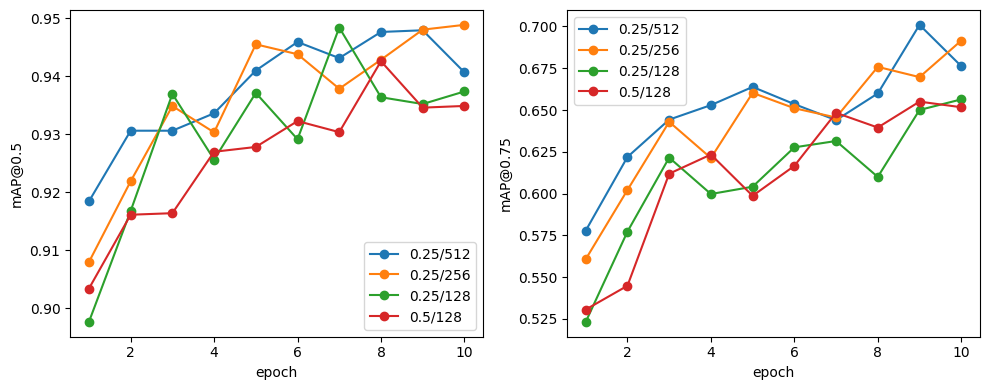

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for name, frac, bs in ROI_NAMES:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    label = f"{frac}/{bs}"
    ax[0].plot(df["epoch"], df["map50"], marker="o", label=label)
    ax[1].plot(df["epoch"], df["map75"], marker="o", label=label)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("mAP@0.5"); ax[0].legend()
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("mAP@0.75"); ax[1].legend()
plt.tight_layout()
plt.show()

The RPN does not invent boxes from scratch. On each FPN level it places a fixed set of anchors and only learns how to shift them. Torchvision pairs one scale per pyramid level: (32, 64, 128, 256, 512) with three aspect ratios (0.5, 1.0, 2.0)

In [ ]:
from torchvision.models.detection.rpn import AnchorGenerator

def build_fasterrcnn(num_classes=NUM_CLASSES, trainable_backbone_layers=3, box_batch_size_per_image=512, box_positive_fraction=0.25, anchor_sizes=None):
    weights = FasterRCNN_ResNet50_FPN_V2_Weights.COCO_V1
    model = fasterrcnn_resnet50_fpn_v2(weights=weights, trainable_backbone_layers=trainable_backbone_layers, box_batch_size_per_image=box_batch_size_per_image, box_positive_fraction=box_positive_fraction)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    if anchor_sizes is not None:
        model.rpn.anchor_generator = AnchorGenerator(
            sizes=anchor_sizes,
            aspect_ratios=((0.5, 1.0, 2.0),) * len(anchor_sizes),)
    
    model.transform.min_size = (640,)
    model.transform.max_size = 640
    return model

In [16]:
ANCHOR_RUNS = [
    {"name": "small_shift", "anchor_sizes": ((16,), (32,), (64,), (128,), (256,))},
    {"name": "tiny_shift",  "anchor_sizes": ((8,), (16,), (32,), (64,), (128,))},
]

results = []
for spec in ANCHOR_RUNS:
    set_seed(42)
    model = build_fasterrcnn(trainable_backbone_layers=3, anchor_sizes=spec["anchor_sizes"])
    model.to(device)
    load_checkpoint(RUNS / "fasterrcnn_v2_freeze_head" / "weights" / "best.pt", model)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
    run_dir = make_run_dir(RUNS, f"fasterrcnn_v2_unfreeze_l3_{spec['name']}_hyper")
    save_run_config(run_dir, {
        "lr": 0.005,
        "weight_decay": 0.0005,
        "epochs": 10,
        "trainable_backbone_layers": 3,
        "anchor_sizes": spec["anchor_sizes"],
        "aspect_ratios": (0.5, 1.0, 2.0),
        "optimizer": "SGD",
        "start_checkpoint": "fasterrcnn_v2_freeze_head/weights/best.pt",
    })

    try:
        train_detection_run(model, optimizer, train_loader, val_loader, device, run_dir, epochs=10,)
        df = pd.read_csv(run_dir / "metrics.csv")
        best = df.loc[df["map50"].idxmax()]
        results.append({
            "run": run_dir.name,
            "anchor_sizes": spec["anchor_sizes"],
            "best_epoch": int(best["epoch"]),
            "map50": float(best["map50"]),
            "map75": float(best["map75"]),
            "ap50_fire": float(best["ap50_fire"]),
            "ap50_smoke": float(best["ap50_smoke"]),
            "val_total": float(best["val_total"]),
        })
    except Exception as e:
        print(f"failed {spec['name']}: {e}")

pd.DataFrame(results)

Epoch 1, Step 200, Loss: 0.057286446718499064
Epoch 1, Step 400, Loss: 0.06027959073893726
AP@0.50  fire: 0.954
AP@0.50  smoke: 0.852
mAP@0.50: 0.903
AP@0.75  fire: 0.676
AP@0.75  smoke: 0.392
mAP@0.75: 0.534
Epoch 1: val_total 0.06968478675634583, map50 0.9031833814799907, map75 0.5341574658804696, 183.05999851226807s
Epoch 2, Step 200, Loss: 0.06514427970163524
Epoch 2, Step 400, Loss: 0.06469596522860228
AP@0.50  fire: 0.958
AP@0.50  smoke: 0.870
mAP@0.50: 0.914
AP@0.75  fire: 0.702
AP@0.75  smoke: 0.469
mAP@0.75: 0.585
Epoch 2: val_total 0.07193243862386861, map50 0.9142021234525757, map75 0.5851888265417196, 183.0119342803955s
Epoch 3, Step 200, Loss: 0.062314139418303965
Epoch 3, Step 400, Loss: 0.06394729524850845
AP@0.50  fire: 0.958
AP@0.50  smoke: 0.899
mAP@0.50: 0.928
AP@0.75  fire: 0.756
AP@0.75  smoke: 0.506
mAP@0.75: 0.631
Epoch 3: val_total 0.07554423386242493, map50 0.9283189259168696, map75 0.6312131202437945, 183.04288029670715s
Epoch 4, Step 200, Loss: 0.063494333233

,run,anchor_sizes,best_epoch,map50,map75,ap50_fire,ap50_smoke,val_total
0,fasterrcnn_v2_unfreeze_l3_small_shift_hyper,"((16,), (32,), (64,), (128,), (256,))",9,0.948980,0.665185,0.969872,0.928087,0.077768
1,fasterrcnn_v2_unfreeze_l3_tiny_shift_hyper,"((8,), (16,), (32,), (64,), (128,))",10,0.925382,0.621408,0.954159,0.896604,0.034721


Default FPN scales (32, 64, 128, 256, 512) stay. Shifting one level down left mAP@0.5 unchanged and raised fire AP only slightly while mAP@0.75 dropped from 0.701 to 0.665. Dropping the 512-px prior hurts large smoke and fire more than the extra small-object coverage helps. Shifting two levels was worse on every AP metric. We keep the default generator and do not change aspect ratios.

FPN produces five feature maps (P2-P6), all with 256 channels and feeds them directly to the RPN and box head. We add a shared Squeeze-and-Excitation block right after the backbone it pools each channel to one number learns a small 256->16->256 gate and rescales the feature maps channel-wise before anything downstream sees them. The goal is to let the network learn which of the 256 channels matter most for fire/smoke on top of an otherwise unchanged COCO-pretrained detector. We use one shared SE block for all five levels to keep the added parameter count small and avoid overfitting on our dataset size

In [18]:
import torch.nn as nn

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 8) # hidden will be 16 for our case because channels=256 for the FPN output of our model
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), # squeeze: (B, C, H, W) -> (B, C, 1, 1) adaptive because it decides the kernel and stride based on given output size
            nn.Conv2d(channels, hidden, kernel_size=1, bias=True), # Excitation 1st half
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, kernel_size=1, bias=True), # Excitation 2nd half
            nn.Sigmoid()
            ) 
    def forward(self, x):
        return x * self.fc(x) # original input multiplied by the output of the SE block channel wise so the output is scaled by the learned weights for each channel

def attach_fpn_se(model):
    se = SEBlock(channels=model.backbone.out_channels) # fpn's output channels is 256 for resnet50 backbone
    model.fpn_se = se # se block added as an attribute to the model, model.parameters will be able to see the moddel.fpn_se parameters because it is an attribute of the model

    def hook(module, inputs, outputs):
        return {k: se(v) for k, v in outputs.items()} # apply the se block to each output of the fpn

    model.backbone.register_forward_hook(hook)
    return model

In [19]:
set_seed(42)
model = build_fasterrcnn(trainable_backbone_layers=3)
model.to(device)
load_checkpoint(RUNS / "fasterrcnn_v2_freeze_head" / "weights" / "best.pt", model)
attach_fpn_se(model)
model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(640,), max_size=640, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        

In [20]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
run_dir = make_run_dir(RUNS, "fasterrcnn_v2_unfreeze_l3_fpnse_hyper")
save_run_config(run_dir, {
    "lr": 0.005,
    "weight_decay": 0.0005,
    "epochs": 10,
    "trainable_backbone_layers": 3,
    "optimizer": "SGD",
    "architecture": "fpn_se_shared_reduction16",
    "start_checkpoint": "fasterrcnn_v2_freeze_head/weights/best.pt",
})
train_detection_run(model, optimizer, train_loader, val_loader, device, run_dir, epochs=10)

Epoch 1, Step 200, Loss: 0.1225242012552917
Epoch 1, Step 400, Loss: 0.12065676758997142
AP@0.50  fire: 0.951
AP@0.50  smoke: 0.862
mAP@0.50: 0.906
AP@0.75  fire: 0.699
AP@0.75  smoke: 0.450
mAP@0.75: 0.574
Epoch 1: val_total 0.12152486180235272, map50 0.9063752615412628, map75 0.5744602790073352, 178.9746539592743s
Epoch 2, Step 200, Loss: 0.10670491525903344
Epoch 2, Step 400, Loss: 0.10842359923757612
AP@0.50  fire: 0.962
AP@0.50  smoke: 0.899
mAP@0.50: 0.931
AP@0.75  fire: 0.699
AP@0.75  smoke: 0.486
mAP@0.75: 0.592
Epoch 2: val_total 0.11505748594374013, map50 0.9307623738574347, map75 0.5922257455023849, 178.69193983078003s
Epoch 3, Step 200, Loss: 0.10023343803361058
Epoch 3, Step 400, Loss: 0.09857943082228303
AP@0.50  fire: 0.964
AP@0.50  smoke: 0.911
mAP@0.50: 0.938
AP@0.75  fire: 0.718
AP@0.75  smoke: 0.557
mAP@0.75: 0.637
Epoch 3: val_total 0.1096050486060008, map50 0.9376886218361108, map75 0.6373779626518548, 178.08798742294312s
Epoch 4, Step 200, Loss: 0.0909814684838056

In [21]:
df = pd.read_csv(run_dir / "metrics.csv")
best = df.loc[df["map50"].idxmax()]
pd.DataFrame([{
    "run": run_dir.name,
    "best_epoch": int(best["epoch"]),
    "map50": float(best["map50"]),
    "map75": float(best["map75"]),
    "ap50_fire": float(best["ap50_fire"]),
    "ap50_smoke": float(best["ap50_smoke"]),
    "val_total": float(best["val_total"]),
}])

,run,best_epoch,map50,map75,ap50_fire,ap50_smoke,val_total
0,fasterrcnn_v2_unfreeze_l3_fpnse_hyper,9,0.951207,0.671917,0.971959,0.930456,0.102378


So far every run used a constant learning rate. A constant rate takes the same size step on epoch 1 and epoch 10 even though the model should settle into finer adjustments as training progresses. Switching from freeze_head to unfreeze_l3 also suddenly makes many more parameters trainable so the first steps risk being too aggressive. We test three schedules: cosine decay over all 10 epochs, step decay (drop by 10x at epochs 6 and 9), and a 2-epoch linear warmup followed by cosine decay

In [22]:
from torch.optim.lr_scheduler import CosineAnnealingLR, MultiStepLR, LinearLR, SequentialLR

def build_scheduler(kind, optimizer, epochs):
    if kind == "cosine":
        return CosineAnnealingLR(optimizer, T_max=epochs)
    if kind == "step_6_9":
        return MultiStepLR(optimizer, milestones=[6, 9], gamma=0.1) # drop by 0.1 at epoch 6 and 9
    if kind == "warmup2_cosine":
        warmup = LinearLR(optimizer, start_factor=0.1, total_iters=2) # warmup is lr*0.1 for 2 epochs
        cosine = CosineAnnealingLR(optimizer, T_max=epochs-2, eta_min=1e-5)
        return SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[2])

In [23]:
SCHEDULER_RUNS = [
    {"name": "cosine"},
    {"name": "step_6_9"},
    {"name": "warmup2_cosine"},
]

results= []
for spec in SCHEDULER_RUNS:
    set_seed(42)
    model = build_fasterrcnn(trainable_backbone_layers=3)
    model.to(device)
    load_checkpoint(RUNS / "fasterrcnn_v2_freeze_head" / "weights" / "best.pt", model)

    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
    scheduler = build_scheduler(spec["name"], optimizer, epochs=10)

    run_dir = make_run_dir(RUNS, f"fasterrcnn_v2_unfreeze_l3_{spec['name']}_hyper")
    save_run_config(run_dir, {
        "lr": 0.005,
        "weight_decay": 0.0005,
        "epochs": 10,
        "trainable_backbone_layers": 3,
        "scheduler": spec["name"],
        "optimizer": "SGD",
        "start_checkpoint": "fasterrcnn_v2_freeze_head/weights/best.pt",
    })

    try:
        train_detection_run(model, optimizer, train_loader, val_loader, device, run_dir, epochs=10, scheduler=scheduler)
        df = pd.read_csv(run_dir / "metrics.csv")
        best = df.loc[df["map50"].idxmax()]
        results.append({
            "run": run_dir.name,
            "scheduler": spec["name"],
            "best_epoch": int(best["epoch"]),
            "map50": float(best["map50"]),
            "map75": float(best["map75"]),
            "ap50_fire": float(best["ap50_fire"]),
            "ap50_smoke": float(best["ap50_smoke"]),
            "val_total": float(best["val_total"]),
        })
    except Exception as e:
        print(f"failed {spec['name']}: {e}")

Epoch 1, Step 200, Loss: 0.11260192995890975
Epoch 1, Step 400, Loss: 0.11389352586120367
AP@0.50  fire: 0.958
AP@0.50  smoke: 0.872
mAP@0.50: 0.915
AP@0.75  fire: 0.721
AP@0.75  smoke: 0.454
mAP@0.75: 0.587
Epoch 1: val_total 0.11381776082369448, map50 0.9148937302683925, map75 0.5874755377753419, 175.04652500152588s
Epoch 2, Step 200, Loss: 0.10741874385625123
Epoch 2, Step 400, Loss: 0.10493791220709682
AP@0.50  fire: 0.961
AP@0.50  smoke: 0.893
mAP@0.50: 0.927
AP@0.75  fire: 0.696
AP@0.75  smoke: 0.530
mAP@0.75: 0.613
Epoch 2: val_total 0.11035387437402105, map50 0.9269126530479043, map75 0.612853573058851, 175.00161743164062s
Epoch 3, Step 200, Loss: 0.09444095764309168
Epoch 3, Step 400, Loss: 0.09590404427610338
AP@0.50  fire: 0.962
AP@0.50  smoke: 0.907
mAP@0.50: 0.934
AP@0.75  fire: 0.765
AP@0.75  smoke: 0.531
mAP@0.75: 0.648
Epoch 3: val_total 0.1069227285637446, map50 0.9342389745332884, map75 0.6480908891299513, 175.68776059150696s
Epoch 4, Step 200, Loss: 0.088879192247986

In [9]:
SCHEDULER_NAMES = [
    ("fasterrcnn_v2_unfreeze_l3_lr0005_hyper", "constant"),
    ("fasterrcnn_v2_unfreeze_l3_cosine_hyper", "cosine"),
    ("fasterrcnn_v2_unfreeze_l3_step_6_9_hyper", "step_6_9"),
    ("fasterrcnn_v2_unfreeze_l3_warmup2_cosine_hyper", "warmup2_cosine"),
]

rows = []
for name, sched in SCHEDULER_NAMES:
    df = pd.read_csv(RUNS / name / "metrics.csv")
    best = df.loc[df["map50"].idxmax()]
    rows.append({
        "run": name,
        "scheduler": sched,
        "best_epoch": int(best["epoch"]),
        "map50": float(best["map50"]),
        "map75": float(best["map75"]),
        "ap50_fire": float(best["ap50_fire"]),
        "ap50_smoke": float(best["ap50_smoke"]),
        "val_total": float(best["val_total"]),
    })

pd.DataFrame(rows)

,run,scheduler,best_epoch,map50,map75,ap50_fire,ap50_smoke,val_total
0,fasterrcnn_v2_unfreeze_l3_lr0005_hyper,constant,9,0.947919,0.700972,0.966278,0.929559,0.102411
1,fasterrcnn_v2_unfreeze_l3_cosine_hyper,cosine,9,0.949704,0.702977,0.973432,0.925976,0.099378
2,fasterrcnn_v2_unfreeze_l3_step_6_9_hyper,step_6_9,7,0.953244,0.709412,0.973642,0.932846,0.097798
3,fasterrcnn_v2_unfreeze_l3_warmup2_cosine_hyper,warmup2_cosine,10,0.952607,0.702710,0.969981,0.935233,0.100196


step_6_9 is the best schedule. Dropping the learning rate by 10x at epoch 6 (and again at 9) raised mAP@0.5 from 0.948 to 0.953 and mAP@0.75 from 0.701 to 0.709 versus constant lr. Both fire and smoke improved. Cosine was almost identical to constant lr. The 2-epoch warmup plus cosine caught up on mAP@0.5 but not on mAP@0.75.

We keep MultiStepLR on top of lr=0.005, wd=0.0005, layers=3, SGD.

After unfreeze the backbone still holds COCO features while the RPN and box head are the parts that must adapt to fire and smoke. Using one learning rate for both can either move the backbone too far or leave the heads too slow. So we split the optimizer into two groups a lower lr on backbone (ResNet+FPN) and the previous lr=0.005 on everything else (RPN + box head). 

In [ ]:
def build_discriminative_optimizer(model, backbone_lr, head_lr, prefix="backbone.", momentum=0.9, weight_decay=0.0005):
    slow_params = [p for n, p in model.named_parameters() if p.requires_grad and n.startswith(prefix)]
    fast_params = [p for n, p in model.named_parameters() if p.requires_grad and not n.startswith(prefix)]

    print(f"{len(slow_params)} slow params {len(fast_params)} fast params")
    
    return torch.optim.SGD([
        {"params": slow_params, "lr": backbone_lr},
        {"params": fast_params, "lr": head_lr}
    ], momentum=momentum, weight_decay=weight_decay)

In [10]:
from torch.optim.lr_scheduler import MultiStepLR

In [13]:
DISC_RUNS = [
    {"name": "disc_5x", "backbone_lr": 0.001, "head_lr": 0.005, "prefix": "backbone."},
    {"name": "disc_10x", "backbone_lr": 0.0005, "head_lr": 0.005, "prefix": "backbone."},
    {"name": "disc_10x_body", "backbone_lr": 0.0005, "head_lr": 0.005, "prefix": "backbone.body."},
]

results = []
for spec in DISC_RUNS:
    set_seed(42)
    model = build_fasterrcnn(trainable_backbone_layers=3)
    model.to(device)
    load_checkpoint(RUNS / "fasterrcnn_v2_freeze_head" / "weights" / "best.pt", model)

    optimizer = build_discriminative_optimizer(model, backbone_lr=spec["backbone_lr"], head_lr=spec["head_lr"], prefix=spec["prefix"])
    scheduler = MultiStepLR(optimizer, milestones=[6, 9], gamma=0.1)

    run_dir = make_run_dir(RUNS, f"fasterrcnn_v2_unfreeze_l3_{spec['name']}_hyper")
    save_run_config(run_dir, {
        "head_lr": spec["head_lr"],
        "backbone_lr": spec["backbone_lr"],
        "slow_prefix": spec["prefix"],
        "weight_decay": 0.0005,
        "epochs": 10,
        "trainable_backbone_layers": 3,
        "scheduler": "step_6_9",
        "optimizer": "SGD",
        "start_checkpoint": "fasterrcnn_v2_freeze_head/weights/best.pt",
    })
    try:
        train_detection_run(model, optimizer, train_loader, val_loader, device, run_dir, epochs=10, scheduler=scheduler)
        df = pd.read_csv(run_dir / "metrics.csv")
        best = df.loc[df["map50"].idxmax()]
        results.append({
            "run": run_dir.name,
            "backbone_lr": spec["backbone_lr"],
            "head_lr": spec["head_lr"],
            "slow_prefix": spec["prefix"],
            "best_epoch": int(best["epoch"]),
            "map50": float(best["map50"]),
            "map75": float(best["map75"]),
            "ap50_fire": float(best["ap50_fire"]),
            "ap50_smoke": float(best["ap50_smoke"]),
            "val_total": float(best["val_total"]),
        })
    except Exception as e:
        print(f"failed {spec['name']}: {e}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 233MB/s] 


150 slow params 26 fast params
Epoch 1, Step 200, Loss: 0.11068353934213519
Epoch 1, Step 400, Loss: 0.11082596757449209
AP@0.50  fire: 0.952
AP@0.50  smoke: 0.847
mAP@0.50: 0.900
AP@0.75  fire: 0.690
AP@0.75  smoke: 0.448
mAP@0.75: 0.569
Epoch 1: val_total 0.11690518253145774, map50 0.8996969107025312, map75 0.5691359152848501, 178.15509915351868s
Epoch 2, Step 200, Loss: 0.11000156993046403
Epoch 2, Step 400, Loss: 0.1078757247608155
AP@0.50  fire: 0.952
AP@0.50  smoke: 0.859
mAP@0.50: 0.905
AP@0.75  fire: 0.697
AP@0.75  smoke: 0.478
mAP@0.75: 0.588
Epoch 2: val_total 0.11554083266963988, map50 0.905456430126959, map75 0.5876119258764948, 175.92933225631714s
Epoch 3, Step 200, Loss: 0.10200391897931695
Epoch 3, Step 400, Loss: 0.10320815565995872
AP@0.50  fire: 0.950
AP@0.50  smoke: 0.865
mAP@0.50: 0.907
AP@0.75  fire: 0.731
AP@0.75  smoke: 0.484
mAP@0.75: 0.608
Epoch 3: val_total 0.11405490944447692, map50 0.9072985176239885, map75 0.6076855590516139, 176.02046418190002s
Epoch 4, St

In [14]:
pd.DataFrame(results)

,run,backbone_lr,head_lr,slow_prefix,best_epoch,map50,map75,ap50_fire,ap50_smoke,val_total
0,fasterrcnn_v2_unfreeze_l3_disc_5x_hyper,0.0010,0.005,backbone.,9,0.933428,0.669308,0.961813,0.905042,0.105814
1,fasterrcnn_v2_unfreeze_l3_disc_10x_hyper,0.0005,0.005,backbone.,8,0.928536,0.640244,0.959571,0.897502,0.108150
2,fasterrcnn_v2_unfreeze_l3_disc_10x_body_hyper,0.0005,0.005,backbone.body.,9,0.934578,0.667526,0.964771,0.904386,0.107221


Now we will fully train the best combination with early stopping. Further on if we need any regularization based on the loss we search for best regularizer

In [11]:
set_seed(42)
model = build_fasterrcnn(trainable_backbone_layers=3)
model.to(device)
load_checkpoint(RUNS / "fasterrcnn_v2_freeze_head" / "weights" / "best.pt", model)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
scheduler = MultiStepLR(optimizer, milestones=[16, 22], gamma=0.1)

run_dir = make_run_dir(RUNS, "fasterrcnn_v2_unfreeze_l3_step16_22_es_full")
save_run_config(run_dir, {
    "lr": 0.005,
    "weight_decay": 0.0005,
    "max_epochs": 26,
    "min_epochs": 18,
    "patience": 5,
    "metric": "map50",
    "trainable_backbone_layers": 3,
    "scheduler": "MultiStepLR",
    "milestones": [16, 22],
    "gamma": 0.1,
    "optimizer": "SGD",
    "start_checkpoint": "fasterrcnn_v2_freeze_head/weights/best.pt",
})

In [13]:
train_detection_run(model, optimizer, train_loader, val_loader, device, run_dir, epochs=50, scheduler=scheduler, patience=8, min_epoch=18) # min epoch is 18 because we want to give the model enough time to train with learning rate drops at 16 and 22.

Epoch 1, Step 200, Loss: 0.1133614001609385
Epoch 1, Step 400, Loss: 0.11426149496808648
AP@0.50  fire: 0.955
AP@0.50  smoke: 0.871
mAP@0.50: 0.913
AP@0.75  fire: 0.703
AP@0.75  smoke: 0.446
mAP@0.75: 0.575
Epoch 1: val_total 0.11453613254921569, map50 0.9132907924124072, map75 0.5745013868239048, 177.37082386016846s
Epoch 2, Step 200, Loss: 0.1070748950727284
Epoch 2, Step 400, Loss: 0.10507774773053825
AP@0.50  fire: 0.961
AP@0.50  smoke: 0.889
mAP@0.50: 0.925
AP@0.75  fire: 0.715
AP@0.75  smoke: 0.530
mAP@0.75: 0.622
Epoch 2: val_total 0.11117893100881869, map50 0.9250790766864944, map75 0.6222330635585362, 174.95796418190002s
Epoch 3, Step 200, Loss: 0.09402295667678118
Epoch 3, Step 400, Loss: 0.09595527210272849
AP@0.50  fire: 0.963
AP@0.50  smoke: 0.902
mAP@0.50: 0.933
AP@0.75  fire: 0.754
AP@0.75  smoke: 0.536
mAP@0.75: 0.645
Epoch 3: val_total 0.10632176816097798, map50 0.9326306197616114, map75 0.645176982444623, 175.62840723991394s
Epoch 4, Step 200, Loss: 0.0890168688260018

In [14]:
df = pd.read_csv(run_dir / "metrics.csv")
best = df.loc[df["map50"].idxmax()]
pd.DataFrame([{
    "run": run_dir.name,
    "best_epoch": int(best["epoch"]),
    "map50": float(best["map50"]),
    "map75": float(best["map75"]),
    "ap50_fire": float(best["ap50_fire"]),
    "ap50_smoke": float(best["ap50_smoke"]),
    "val_total": float(best["val_total"]),
}])

,run,best_epoch,map50,map75,ap50_fire,ap50_smoke,val_total
0,fasterrcnn_v2_unfreeze_l3_step16_22_es_full,27,0.951397,0.734621,0.967455,0.935339,0.09678


Extending the winning recipe to a 26-epoch-scale did not raise mAP@0.5. It did raise mAP@0.75 from 0.709 to 0.735 which is the gap we cared about boxes sit tighter on fire and smoke. The best checkpoint is epoch 27 so early stopping did not cut training short. 

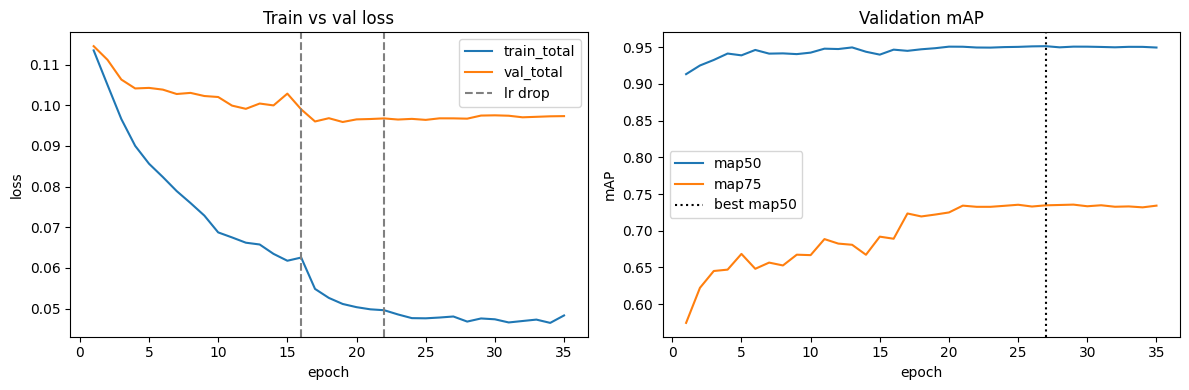

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df["epoch"], df["train_total"], label="train_total")
axes[0].plot(df["epoch"], df["val_total"], label="val_total")
axes[0].axvline(16, linestyle="--", color="gray", label="lr drop")
axes[0].axvline(22, linestyle="--", color="gray")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Train vs val loss")
axes[0].legend()

axes[1].plot(df["epoch"], df["map50"], label="map50")
axes[1].plot(df["epoch"], df["map75"], label="map75")
axes[1].axvline(int(df.loc[df["map50"].idxmax(), "epoch"]), linestyle=":", color="black", label="best map50")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("mAP")
axes[1].set_title("Validation mAP")
axes[1].legend()

fig.tight_layout()
plt.show()

Our loss curves show training loss still falling at epoch 35, while validation loss and mAP have been flat since around epoch 20. The model isn't converging to one clear point anymore it is bouncing around inside a region. Picking a single epoch as the final model means we might just be keeping whichever epoch got lucky.

SWA fixes this by averaging the weights from several epochs inside that flat region instead of picking one. We continue training a few more epochs at a small constant learning rate and average the weights after each epoch. BatchNorm layers need a separate fix afterward their running stats were tuned for the un-averaged weights so we recompute them with one extra pass over the training set. We then compare the averaged model to our current best checkpoint on mAP we only keep it if it does at least as well

In [9]:
import torch.nn as nn
from torch.optim.swa_utils import AveragedModel, SWALR

In [10]:
set_seed(42)
model = build_fasterrcnn(trainable_backbone_layers=3)
model.to(device)
load_checkpoint(RUNS / "fasterrcnn_v2_unfreeze_l3_step16_22_es_full" / "weights" / "best.pt", model)

{'epoch': 27,
 'metric': 0.9513972740681874,
 'model': OrderedDict([('backbone.body.conv1.weight',
               tensor([[[[-6.1102e-03,  9.5599e-03,  3.1568e-02,  ..., -1.4302e-01,
                           4.7951e-02,  2.8355e-02],
                         [-1.0539e-02, -7.9132e-04,  8.8673e-02,  ..., -3.3262e-01,
                           5.0684e-02,  8.0228e-02],
                         [ 5.8592e-03, -8.4502e-03,  5.4741e-02,  ..., -4.0573e-01,
                          -7.0297e-02,  1.4837e-01],
                         ...,
                         [ 4.2638e-03,  2.5437e-02, -4.4603e-02,  ..., -1.1729e-01,
                          -1.7737e-01,  1.0410e-01],
                         [-1.7198e-03, -6.8754e-04, -1.9032e-02,  ..., -3.7532e-02,
                          -7.5427e-02,  3.8558e-02],
                         [-5.2213e-03, -1.4919e-02, -1.0002e-02,  ..., -2.4140e-02,
                          -3.2910e-02, -2.3537e-03]],
               
                        [[ 1.315

use_buffers=True averages the weights and the float BatchNorm stats. The default path also tries to average num_batches_tracked which is an integer counter not a weight. PyTorch then crashes. The custom avg_fn uses the normal SWA formula on floats and just copies integer buffers. I debugged deeply to solve that problem

In [13]:
def swa_avg_fn(averaged_param, model_param, num_averaged):
    if not averaged_param.is_floating_point():
        return model_param
    return averaged_param + (model_param - averaged_param) / (num_averaged + 1)

In [14]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.0005, momentum=0.9, weight_decay=0.0005)
swa_scheduler = SWALR(optimizer, swa_lr=0.0005, anneal_epochs=1, anneal_strategy="cos") # just controls lr does not avg weights.
# Current lr and swa_lr are both 0.0005, so lr stays constant here. 
swa_model = AveragedModel(model, avg_fn=swa_avg_fn, use_buffers=True) # Stores the running average of the model weights and BatchNorm statistics.

SWA_EPOCHS = 6
run_dir = make_run_dir(RUNS, "fasterrcnn_v2_unfreeze_l3_swa")
save_run_config(run_dir, {
    "base_checkpoint": "fasterrcnn_v2_unfreeze_l3_step16_22_es_full/weights/best.pt",
    "swa_lr": 0.0005,
    "swa_epochs": SWA_EPOCHS,
    "weight_decay": 0.0005,
})

In [15]:
for epoch in range(1, SWA_EPOCHS +1):
    model.train()
    running = 0.0
    n = 0
    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running += loss.item()
        n += 1

    swa_model.update_parameters(model) # Add this epochs weights to the running average. This is the line that actually performs SWA.
    swa_scheduler.step() # update the learning rate for the next epoch (stays at 0.0005 at our configuration)
    print(f"SWA epoch {epoch}: train_loss {running/n}, lr {optimizer.param_groups[0]['lr']}")

SWA epoch 1: train_loss 0.046815967278890924, lr 0.0005
SWA epoch 2: train_loss 0.04672955228473808, lr 0.0005
SWA epoch 3: train_loss 0.04580267880600496, lr 0.0005
SWA epoch 4: train_loss 0.04568058754256392, lr 0.0005
SWA epoch 5: train_loss 0.045231628269873196, lr 0.0005
SWA epoch 6: train_loss 0.04522531813575474, lr 0.0005


after epoch 1:  W_swa = W1
after epoch 2: W_swa = (W1 + W2) / 2
after epoch 3: W_swa = (W1 + W2 + W3) / 3

The same running-average logic is also applied to BatchNorm statistics because

In [16]:
map50_swa, aps50_swa = evaluate_map(swa_model, val_loader, device, iou_thresh=0.5)
map75_swa, aps75_swa = evaluate_map(swa_model, val_loader, device, iou_thresh=0.75)

AP@0.50  fire: 0.967
AP@0.50  smoke: 0.931
mAP@0.50: 0.949
AP@0.75  fire: 0.825
AP@0.75  smoke: 0.646
mAP@0.75: 0.735


In [17]:
pd.DataFrame([{
        "run": "swa",
        "map50": float(map50_swa),
        "map75": float(map75_swa),
        "ap50_fire": float(aps50_swa.get("fire")),
        "ap50_smoke": float(aps50_swa.get("smoke")),},])

,run,map50,map75,ap50_fire,ap50_smoke
0,swa,0.949038,0.735273,0.967071,0.931005


In [18]:
torch.save(
    {"model": swa_model.module.state_dict()},
    run_dir / "weights" / "swa.pt",
)

SWA did not beat the current best checkpoint. map50 dropped from 0.951 to 0.949 and smoke AP50 fell slightly. map75 is essentially unchanged